**Note: Run servers on local instead of Colab**





In [1]:
!pip install --quiet flask flask-ngrok scikit-learn joblib



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\Talha\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
import joblib

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
])
pipeline.fit(X_train, y_train)
joblib.dump(pipeline, 'model.joblib')


['model.joblib']

In [4]:
%%writefile app.py
from flask import Flask, request, jsonify
from flask_ngrok import run_with_ngrok
import joblib

app = Flask(__name__)
run_with_ngrok(app)
model = joblib.load('model.joblib')

@app.route('/predict', methods=['POST'])
def predict():
    data = request.get_json()
    features = data['features']
    pred = model.predict([features])[0]
    return jsonify({'prediction': int(pred)})

@app.route('/health', methods=['GET'])
def health():
    return 'OK', 200

if __name__ == '__main__':
    app.run()


Overwriting app.py


In [5]:
!python app.py


^C


In [6]:
import requests
payload = {'features': X_test[0].tolist()}
print(requests.post('http://127.0.0.1:5000/predict', json=payload).json())


{'prediction': 1}



## Exercise: Model Serialization & Deployment

### 1. Data Preparation  
- Load the Breast Cancer Wisconsin dataset with `sklearn.datasets.load_breast_cancer`  ([Save and Load Machine Learning Models in Python with scikit-learn](https://www.geeksforgeeks.org/save-and-load-machine-learning-models-in-python-with-scikit-learn/?utm_source=chatgpt.com)).  
- Split into train/test (80/20) and standardize features with `StandardScaler`  ([Save and Load Machine Learning Models in Python with scikit-learn](https://www.geeksforgeeks.org/save-and-load-machine-learning-models-in-python-with-scikit-learn/?utm_source=chatgpt.com)).  

### 2. Pipeline Construction  
- Build a scikit-learn `Pipeline` combining `StandardScaler` and `RandomForestClassifier(n_estimators=100, random_state=42)`  ([Model Serialization using pickle and joblib - Kaggle](https://www.kaggle.com/code/tasnimniger/model-serialization-using-pickle-and-joblib?utm_source=chatgpt.com)).  
- Fit the pipeline on the training data.  

### 3. Serialization  
- Save the fitted pipeline as `model_v1.pkl` using `pickle.dump(..., protocol=5)`  ([Save Machine Learning Model Using Pickle and Joblib](https://www.analyticsvidhya.com/blog/2021/08/quick-hacks-to-save-machine-learning-model-using-pickle-and-joblib/?utm_source=chatgpt.com)).  
- Save the same pipeline as `model_v1.joblib` with `joblib.dump(...)`  ([STEP 2: Model serialization and pickling | AI Planet (formerly DPhi)](https://aiplanet.com/learn/machine-learning-bootcamp/module-6-model-deployment/840/step-2-model-serialization-and-pickling?utm_source=chatgpt.com)).  

### 4. Version Control & Metadata  
- Retrain the pipeline twice more with different `random_state` values (e.g., 24, 2025) and save as `model_v2.[pkl|joblib]`, `model_v3.[pkl|joblib]`.  
- Create `model_metadata.json` capturing for each version: `{version, filename, saved_at}` in ISO format  ([Save and Load Machine Learning Models in Python with scikit-learn](https://machinelearningmastery.com/save-load-machine-learning-models-python-scikit-learn/?utm_source=chatgpt.com)).  

### 5. Deserialization & Validation  
- Load each Pickle and Joblib file, run `.predict()` on the standardized test set, and compute accuracy with `sklearn.metrics.accuracy_score`.  
- Verify that all versions produce expected accuracy and identical predictions across formats  ([Save Machine Learning Model Using Pickle and Joblib](https://www.analyticsvidhya.com/blog/2021/08/quick-hacks-to-save-machine-learning-model-using-pickle-and-joblib/?utm_source=chatgpt.com)).  

### 6. Benchmarking  
- Measure and compare file sizes (`os.path.getsize`) and load times (`time.time()` deltas) for Pickle vs Joblib  ([Use Of Pickle & Joblib To Dump And Load Machine Learning Model](https://www.youtube.com/watch?v=N4HO1HDuK4o&utm_source=chatgpt.com)).  
- Plot or tabulate the results in your notebook.  

### 7. (Bonus) Minimal REST API  
- Implement a Flask app (`app.py`) exposing two endpoints:  
  - `GET /models` → returns `model_metadata.json`.  
  - `POST /predict` → accepts JSON `{"features": […]}`, loads the **latest** model version, and returns `{"prediction": <class>}`  ([How to Save Trained Model in Python - Neptune.ai](https://neptune.ai/blog/saving-trained-model-in-python?utm_source=chatgpt.com)).  
- Demonstrate usage via Python’s `requests` in Colab.  

### Deliverables  
1. A Colab notebook with all code cells.  
2. Saved model files (`.pkl`, `.joblib`) and `model_metadata.json`.  
3. A brief markdown report comparing Pickle vs Joblib (size, speed).  
4. (Optional) Flask app code and sample requests.

In [25]:
# 1. Data Preparation
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pickle
import joblib
import json
import os
import time
from datetime import datetime

In [26]:
# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [27]:
# 2. Pipeline Construction
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
])
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('clf', RandomForestClassifier(random_state=42))])

In [28]:
# 3. Serialization
with open('model_v1.pkl', 'wb') as f:
    pickle.dump(pipeline, f, protocol=5)
joblib.dump(pipeline, 'model_v1.joblib')

['model_v1.joblib']

In [29]:
metadata = []
def save_model(version, random_state):
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(n_estimators=100, random_state=random_state))
    ])
    pipe.fit(X_train, y_train)
    
    pkl_file = f'model_{version}.pkl'
    joblib_file = f'model_{version}.joblib'
    
    with open(pkl_file, 'wb') as f:
        pickle.dump(pipe, f, protocol=5)
    joblib.dump(pipe, joblib_file)

    timestamp = datetime.now().isoformat()
    metadata.append({"version": version, "filename": pkl_file, "saved_at": timestamp})
    metadata.append({"version": version, "filename": joblib_file, "saved_at": timestamp})

    return pipe


models = []
models.append(("v1", pipeline))
models.append(("v2", save_model("v2", 24)))
models.append(("v3", save_model("v3", 2025)))

# Save metadata
with open('model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)

In [31]:
# 5. Deserialization & Validation
for version in ["v1", "v2", "v3"]:
    with open(f'model_{version}.pkl', 'rb') as f:
        pkl_model = pickle.load(f)
    joblib_model = joblib.load(f'model_{version}.joblib')

    X_test_scaled = StandardScaler().fit(X_train).transform(X_test)  # consistent scaling
    print(f"{version} Pickle Accuracy:", accuracy_score(y_test, pkl_model.predict(X_test)))
    print(f"{version} Joblib Accuracy:", accuracy_score(y_test, joblib_model.predict(X_test)))

v1 Pickle Accuracy: 0.9649122807017544
v1 Joblib Accuracy: 0.9649122807017544
v2 Pickle Accuracy: 0.9649122807017544
v2 Joblib Accuracy: 0.9649122807017544
v3 Pickle Accuracy: 0.956140350877193
v3 Joblib Accuracy: 0.956140350877193


In [32]:
# 6. Benchmarking
results = []
for version in ["v1", "v2", "v3"]:
    pkl_path = f'model_{version}.pkl'
    joblib_path = f'model_{version}.joblib'

    pkl_size = os.path.getsize(pkl_path)
    joblib_size = os.path.getsize(joblib_path)

    start = time.time()
    with open(pkl_path, 'rb') as f:
        pickle.load(f)
    pkl_time = time.time() - start

    start = time.time()
    joblib.load(joblib_path)
    joblib_time = time.time() - start

    results.append({
        "version": version,
        "pkl_size": pkl_size,
        "joblib_size": joblib_size,
        "pkl_load_time": pkl_time,
        "joblib_load_time": joblib_time
    })

  version  pkl_size  joblib_size  pkl_load_time  joblib_load_time
0      v1    315651       326434       0.008978          0.066005
1      v2    322371       333154       0.007476          0.028910
2      v3    323972       334754       0.008148          0.033084


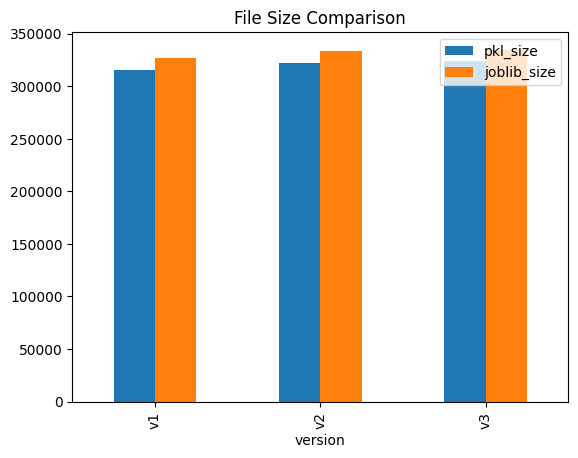

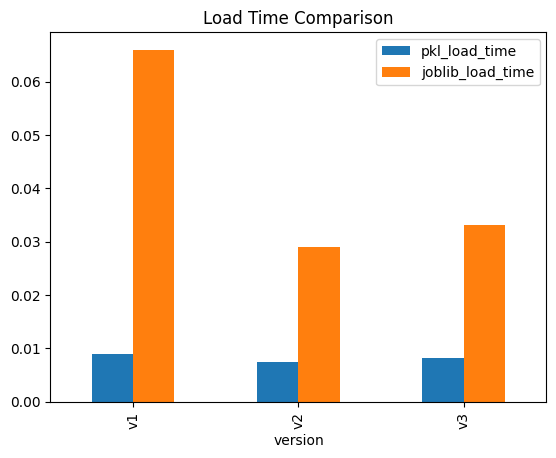

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(results)
print(df)

df.plot(x="version", y=["pkl_size", "joblib_size"], kind="bar", title="File Size Comparison")
plt.show()
df.plot(x="version", y=["pkl_load_time", "joblib_load_time"], kind="bar", title="Load Time Comparison")
plt.show()